# Cheng NN：模擬訓練與資料診斷

這份 notebook **只讀已生成的資料、訓練紀錄及最佳模型的預測**，不會重新生成資料或啟動訓練。

- 訓練中：可看 train／validation 的輸入分布與 loss 曲線；重跑下方 cells 可更新。
- 訓練完成：比較相同最佳 checkpoint 的係數、GEV 支撐範圍及條件式 return level 誤差。
- **預設不讀 test。** 用 train／validation 調參與調整模擬範圍；最後鎖定方案再設 `SHOW_TEST=True`。若依 test 結果反覆改模型，該 test 就不再是獨立的最後驗證，應另生成新測試集。

每筆資料是一整段 50 年序列；RMSE 的真值是模擬時已知的生成係數，不是真實氣候的未知參數。


In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (CURRENT, *CURRENT.parents) if (p / 'src' / 'cheng_nn_simulation.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook inside fast_parameter_using_NN.')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from cheng_nn_diagnostics import (
    resolve_run_directory, load_diagnostic_split, load_saved_predictions,
    coefficient_metrics, plot_distributions, plot_learning_curves,
    plot_coefficient_comparison, plot_prediction_details,
    evaluate_gev_and_rl, validity_by_shape, plot_validity_by_shape,
    plot_rl_by_year, binned_rl_errors, plot_binned_rl_errors,
)

# 指定某次訓練的絕對路徑；None 僅讀 latest_run.json 指向的一次訓練。
RUN_DIR_OVERRIDE = None
SHOW_TEST = False
DETAIL_SPLIT = 'validation'
SAVE_OUTPUTS = True
MAX_PLOT_POINTS = 10_000

RUN_DIR = resolve_run_directory(PROJECT_ROOT, RUN_DIR_OVERRIDE)
run_metadata = {}
if RUN_DIR is not None:
    metadata_path = RUN_DIR / 'run_metadata.json'
    if metadata_path.exists():
        run_metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
DATA_DIR = Path(run_metadata.get('data_directory', PROJECT_ROOT / 'data' / 'simulated' / 'cheng_nn_17d'))
VISIBLE_SPLITS = ['train', 'validation'] + (['test'] if SHOW_TEST else [])
if DETAIL_SPLIT not in VISIBLE_SPLITS:
    raise ValueError('DETAIL_SPLIT is hidden. Reveal test only after locking your model.')
FIGURE_DIR = RUN_DIR / 'figures' if RUN_DIR is not None else None
TABLE_DIR = RUN_DIR / 'diagnostics_tables' if RUN_DIR is not None else None

def show_figure(fig, filename):
    if SAVE_OUTPUTS and FIGURE_DIR is not None:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / filename, dpi=160)
    display(fig)
    plt.close(fig)

def show_table(table, filename, preview_rows=20):
    if SAVE_OUTPUTS and TABLE_DIR is not None:
        TABLE_DIR.mkdir(parents=True, exist_ok=True)
        table.to_csv(TABLE_DIR / filename, index=False)
    display(table.head(preview_rows).round(4))

print('RUN_DIR:', RUN_DIR or 'No run recorded yet; only data diagnostics are available.')
print('Status:', run_metadata.get('status', 'not recorded'))
print('DATA_DIR:', DATA_DIR)
print('Visible splits:', VISIBLE_SPLITS)


RUN_DIR: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\cheng_nn_17d\run_20260929_gpu_01
Status: completed
DATA_DIR: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\simulated\cheng_nn_17d
Visible splits: ['train', 'validation']


## 1. 先看資料有沒有問題

不同 split 的分布應大致相近，但獨立抽樣不會完全重疊。圖片最多抽每個 split 的 10,000 筆，**下方誤差表使用完整 split**。

17 維中，整段標準化後的 `q_0.5` 固定為 0 是正常現象；不代表生成失敗。每段 median／IQR 是在整段資料統一標準化後計算，保留前、中、後期的差異。

原始尺度係數圖可檢查抽樣範圍；標準化係數圖可檢查 NN 實際學習的標籤。不要把這兩個尺度混在一起比較。


,split,sequences,input_dimensions,years_per_sequence,nonfinite_inputs,nonfinite_targets,nonpositive_IQR
0,train,80000,17,50,0,0,0
1,validation,10000,17,50,0,0,0


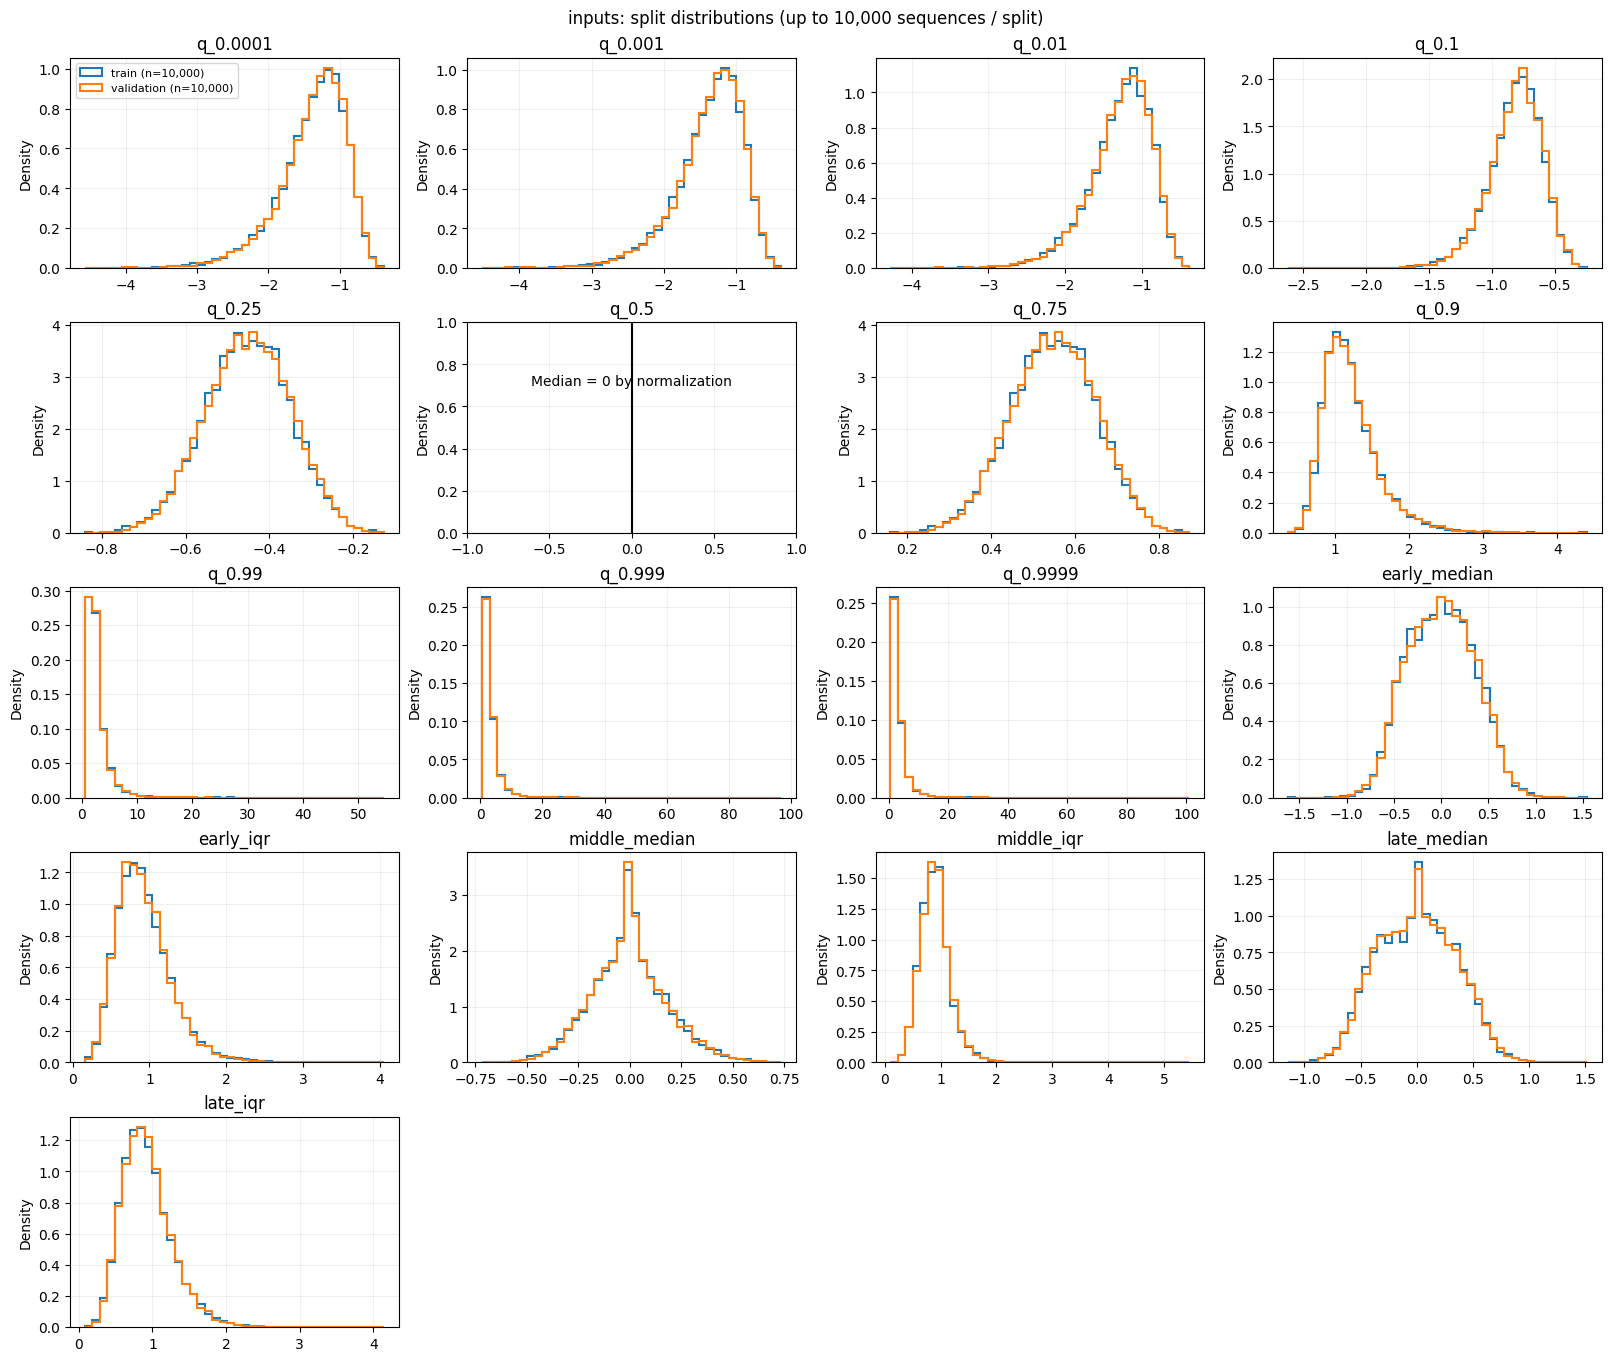

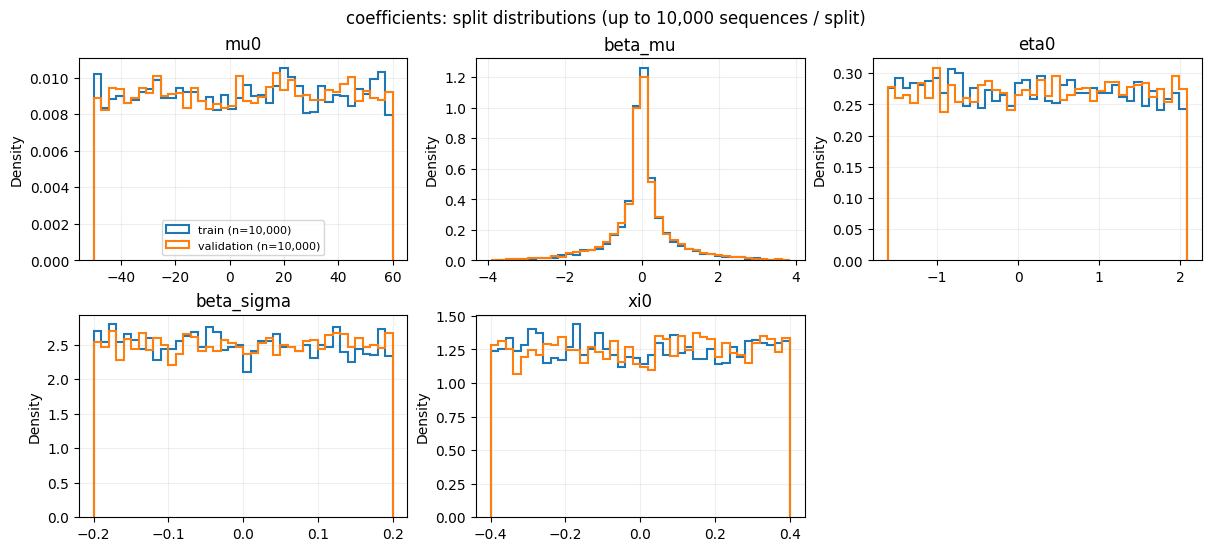

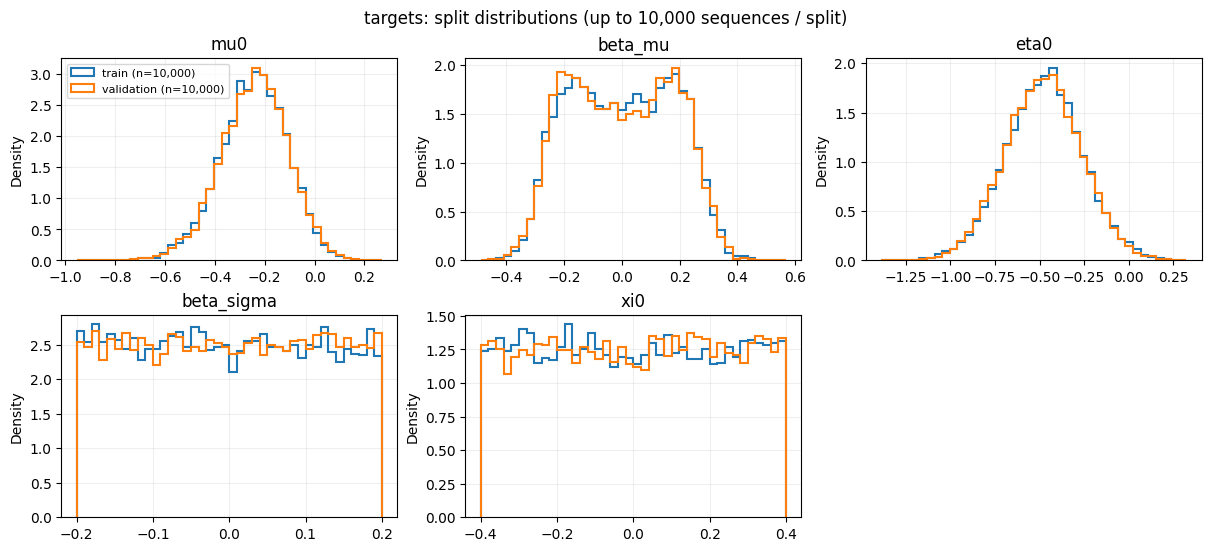

In [2]:
data_by_split = {}
for split in VISIBLE_SPLITS:
    data = load_diagnostic_split(DATA_DIR, split, run_metadata.get('dataset_files_sha256', {}).get(split))
    expected_hash = run_metadata.get('dataset_metadata_sha256', {}).get(split)
    if expected_hash is not None and expected_hash != data['metadata_sha256']:
        raise ValueError(f'{split}: data differ from the selected training run; do not mix old and new results.')
    data_by_split[split] = data

data_summary = pd.DataFrame([
    {'split': split, 'sequences': len(data['inputs']),
     'input_dimensions': data['inputs'].shape[1],
     'years_per_sequence': data['annual_maxima'].shape[1],
     'nonfinite_inputs': int(np.sum(~np.isfinite(data['inputs']))),
     'nonfinite_targets': int(np.sum(~np.isfinite(data['targets']))),
     'nonpositive_IQR': int(np.sum(data['location_scale'][:, 1] <= 0))}
    for split, data in data_by_split.items()
])
show_table(data_summary, 'data_summary.csv')
show_figure(plot_distributions(data_by_split, 'inputs', MAX_PLOT_POINTS), 'diagnostic_input_distributions.png')
show_figure(plot_distributions(data_by_split, 'coefficients', MAX_PLOT_POINTS), 'diagnostic_original_target_distributions.png')
show_figure(plot_distributions(data_by_split, 'targets', MAX_PLOT_POINTS), 'diagnostic_standardized_target_distributions.png')


## 2. 訓練曲線：有沒有過度擬合或還沒學好？

- train 下降、validation 持續上升：可能過度擬合，查看最佳 epoch 與 early stopping。
- 兩條都很高或停滯：檢查 learning rate、輸入摘要能否提供足夠資訊、訓練資料覆蓋及網路能力；不能只憑一張 loss 圖認定原因。
- 這裡的 train loss 是每個 batch 更新權重時記錄的平均，validation 是 epoch 結束後的固定模型。因此**兩者不完全是同一次模型評估**；完成後應再看第 3 節相同最佳 checkpoint 的誤差。

loss 是以 train 標籤均值／標準差縮放後的係數 MSE，不能直接當攝氏度 RMSE。


,epoch,train_loss,validation_loss,learning_rate,seconds,elapsed_seconds
37,38,0.35410,0.41938,0.00025,1.74098,71.58503
38,39,0.35225,0.42143,0.00025,1.86692,73.45195
39,40,0.35067,0.42395,0.00025,1.92487,75.37682
40,41,0.34901,0.42406,0.00012,1.78701,77.16382
41,42,0.34287,0.42440,0.00012,1.77071,78.93453
42,43,0.34132,0.42717,0.00012,1.75031,80.68484
43,44,0.34011,0.42727,0.00012,1.76781,82.45265
44,45,0.33876,0.43007,0.00012,1.73680,84.18945
45,46,0.33762,0.43020,0.00012,1.77428,85.96373
46,47,0.33631,0.43071,0.00012,1.75527,87.71901


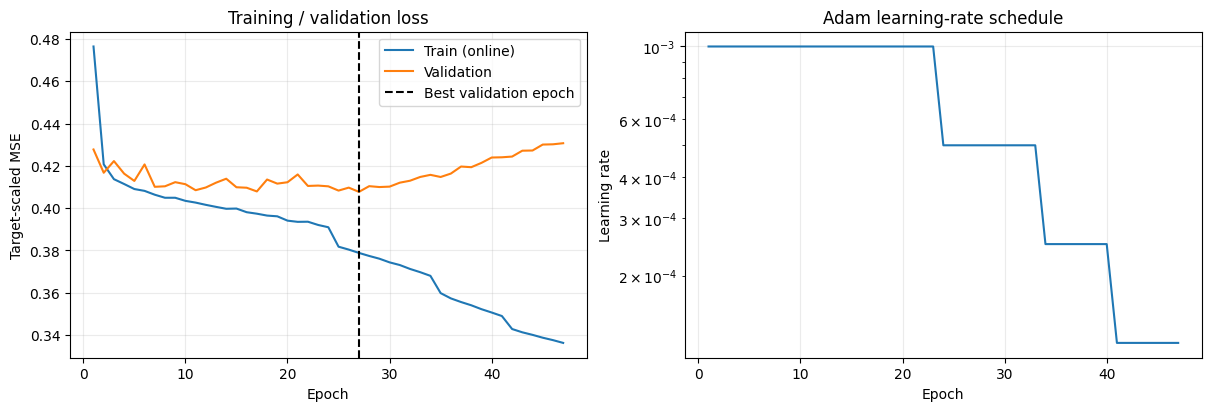

In [3]:
history = pd.DataFrame()
history_path = RUN_DIR / 'training_history.csv' if RUN_DIR is not None else None
if history_path is not None and history_path.exists():
    history = pd.read_csv(history_path)
    if len(history):
        display(history.tail(10).round(5))
        show_figure(plot_learning_curves(history, run_metadata.get('best_epoch')), 'diagnostic_learning_curves.png')
    else:
        print('History exists but the first epoch has not completed.')
else:
    print('No completed epoch record yet. Rerun setup and this block while training.')


## 3. 同一最佳模型：train／validation／test 的係數誤差

只讀目前 `RUN_DIR` 中已完整儲存、metadata 相符的預測。不會拿別次訓練的結果補空缺。訓練尚未產生預測時，本節以後會跳過。

- RMSE：對大誤差較敏感；MAE：平均絕對誤差；bias：預測 − 真值的平均，正值為高估。
- 比較同一係數、同一尺度在不同 split 的差異；五個係數的單位不同，不能靠原始 RMSE 大小排「重要性」。
- `standardized` 指每條序列 median／IQR 對應的係數尺度，尚不是 loss 使用的 train 標籤 z-score。
- 所有有限預測都列入係數誤差；非有限預測另列排除數，不能悄悄刪除讓 RMSE 變漂亮。


,split,scale,coefficient,n_total,n_used,n_excluded,RMSE,MAE,bias
0,train,standardized,mu0,80000,80000,0,0.1035,0.0812,-0.0004
1,train,standardized,beta_mu,80000,80000,0,0.0764,0.0585,-0.0076
2,train,standardized,eta0,80000,80000,0,0.1325,0.1049,0.0051
3,train,standardized,beta_sigma,80000,80000,0,0.0805,0.0645,-0.0006
4,train,standardized,xi0,80000,80000,0,0.1116,0.0880,-0.0001
5,train,original,mu0,80000,80000,0,0.4794,0.2729,0.0112
6,train,original,beta_mu,80000,80000,0,0.3423,0.1933,-0.0249
7,train,original,eta0,80000,80000,0,0.1325,0.1049,0.0051
8,train,original,beta_sigma,80000,80000,0,0.0805,0.0645,-0.0006
9,train,original,xi0,80000,80000,0,0.1116,0.0880,-0.0001


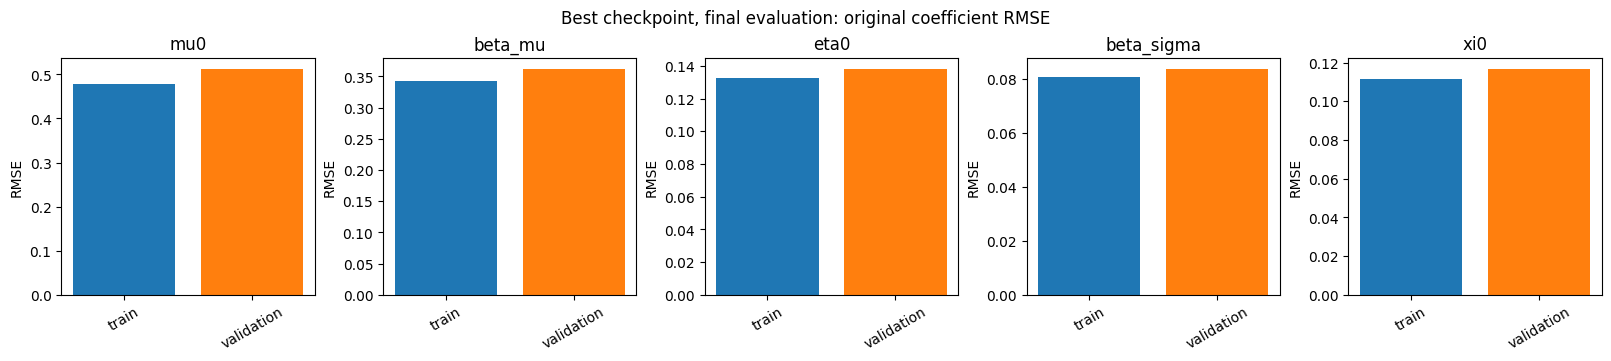

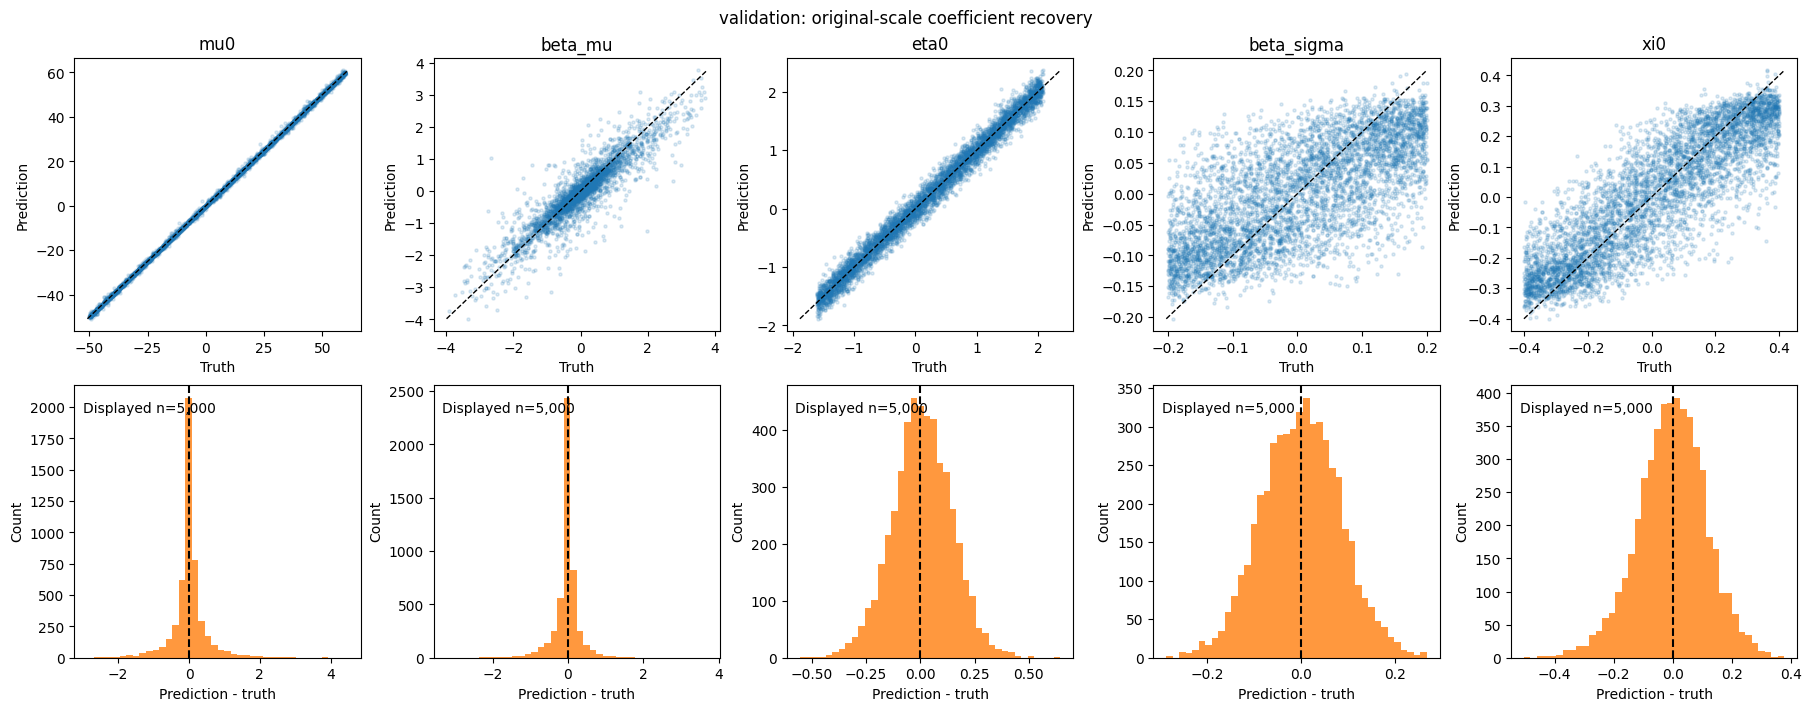

In [4]:
predictions_by_split = {}
if RUN_DIR is not None:
    for split, data in data_by_split.items():
        prediction = load_saved_predictions(RUN_DIR, split, data)
        if prediction is None:
            print(f'{split}: prediction files are not committed yet; skipped.')
        else:
            predictions_by_split[split] = prediction
else:
    print('No training run selected; coefficient evaluation skipped.')

metrics = pd.DataFrame()
if predictions_by_split:
    metrics = coefficient_metrics(data_by_split, predictions_by_split)
    show_table(metrics, 'coefficient_metrics.csv', preview_rows=len(metrics))
    show_figure(plot_coefficient_comparison(metrics, 'original'), 'diagnostic_coefficient_rmse.png')
if DETAIL_SPLIT in predictions_by_split:
    show_figure(
        plot_prediction_details(predictions_by_split[DETAIL_SPLIT]['original'],
                                data_by_split[DETAIL_SPLIT]['coefficients'], DETAIL_SPLIT),
        f'diagnostic_{DETAIL_SPLIT}_coefficient_scatter_residual.png',
    )
else:
    print(f'{DETAIL_SPLIT}: scatter/residual plots are waiting for predictions.')


## 4. 預測參數有沒有形成可用的 GEV？

除了數值有限且尺度為正，每條序列的所有年份都要滿足觀測值的支撐範圍：

$$1+\xi_0\frac{Y_t-\mu(t)}{\sigma(t)}>0.$$

下面以**真實生成的 shape** 分組，檢查失敗是否集中於某些尾部形狀。shape 可以為負、零或正；超過模擬抽樣範圍只是外推警示，不等於數學無效。右圖與表格提供每組樣本數，小樣本組不宜過度解讀。

若參數誤差不大但支撐範圍失敗很多，代表只看 RMSE 不夠；本診斷不會自動裁切 shape 或更改 loss。


,split,n_total,n_valid_all_years,valid_fraction,n_support_failures,n_invalid_parameters,n_outside_xi_training_range
0,train,80000,79948,0.9994,52,0,35
1,validation,10000,9993,0.9993,7,0,8


,left,right,midpoint,n_total,valid_fraction,support_failure_fraction,out_of_range_fraction,split
0,-0.4,-0.3,-0.35,10070,0.9986,0.0014,0.0019,train
1,-0.3,-0.2,-0.25,10083,0.9987,0.0013,0.0002,train
2,-0.2,-0.1,-0.15,10044,0.9989,0.0011,0.0000,train
3,-0.1,0.0,-0.05,9795,0.9994,0.0006,0.0000,train
4,0.0,0.1,0.05,10183,0.9993,0.0007,0.0000,train
5,0.1,0.2,0.15,10072,0.9999,0.0001,0.0000,train
6,0.2,0.3,0.25,9861,1.0000,0.0000,0.0000,train
7,0.3,0.4,0.35,9892,1.0000,0.0000,0.0014,train
8,-0.4,-0.3,-0.35,1221,0.9975,0.0025,0.0033,validation
9,-0.3,-0.2,-0.25,1272,1.0000,0.0000,0.0000,validation


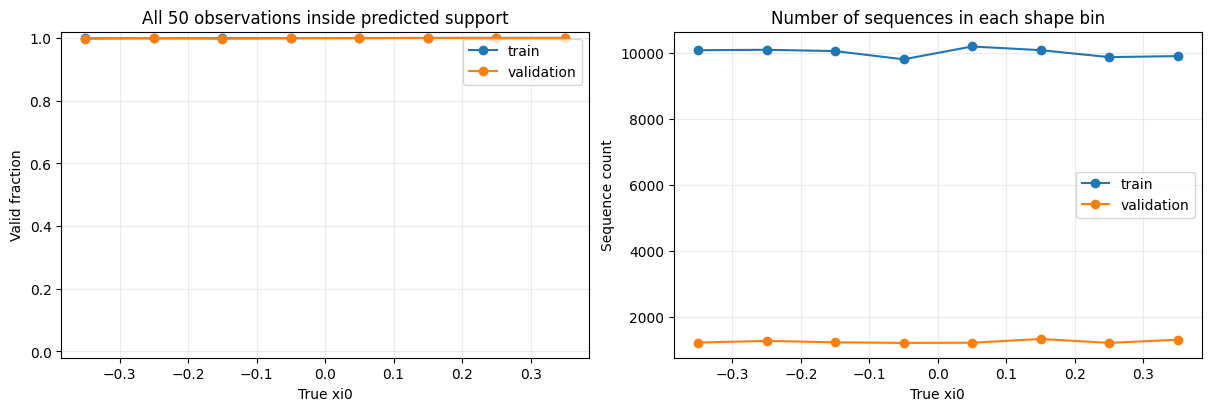

In [5]:
validity_by_split = {}
shape_tables, rl_year_tables, rl_overall_tables = [], [], []
if predictions_by_split:
    for split, prediction in predictions_by_split.items():
        data = data_by_split[split]
        validity, yearly, overall = evaluate_gev_and_rl(data, prediction)
        validity_by_split[split] = validity
        bounds = data['metadata']['parameter_ranges']['xi0']
        shape = validity_by_shape(validity, data['coefficients'][:, 4], np.linspace(*bounds, 9))
        shape_tables.append(shape.assign(split=split))
        rl_year_tables.append(yearly.assign(split=split))
        rl_overall_tables.append(overall.assign(split=split))
        if SAVE_OUTPUTS and TABLE_DIR is not None:
            TABLE_DIR.mkdir(parents=True, exist_ok=True)
            validity.to_csv(TABLE_DIR / f'{split}_gev_validity.csv', index=False)

    validity_summary = pd.DataFrame([
        {'split': split, 'n_total': len(v),
         'n_valid_all_years': int(v['gev_valid_all_years'].sum()),
         'valid_fraction': float(v['gev_valid_all_years'].mean()),
         'n_support_failures': int((v['n_support_violations'] > 0).sum()),
         'n_invalid_parameters': int((~v['parameters_valid_all_years']).sum()),
         'n_outside_xi_training_range': int(v['xi_outside_training_range'].sum())}
        for split, v in validity_by_split.items()
    ])
    shape_summary = pd.concat(shape_tables, ignore_index=True)
    show_table(validity_summary, 'gev_validity_summary.csv')
    show_table(shape_summary, 'gev_validity_by_true_shape.csv', len(shape_summary))
    show_figure(plot_validity_by_shape(shape_summary), 'diagnostic_gev_validity_by_shape.png')
else:
    print('GEV validity evaluation is waiting for saved predictions.')


## 5. 你的最終目標：條件式 RL50(t)、RL100(t)

每一年都用該年的分布計算 $RL_T(t)=F_t^{-1}(1-1/T)$，與模擬真值比較。這是「固定在某一年氣候下的年度分位數」，**不是未來氣候持續改變時的平均等待年數**。

- 實線 `finite_RL`：所有可計算的預測，包含觀測支撐範圍不通過者。
- 虛線 `valid_GEV`：額外要求整條 50 年觀測都在預測支撐範圍內。
- 兩條曲線評估的樣本可能不同，不能只用虛線較低來宣稱模型比較好；同時報告有效率與 `n_excluded`。
- overall 表的樣本數是「序列 × 年份」組合，不是彼此獨立的新資料數。


,return_period,subset,n_total,n_used,n_excluded,used_fraction,RMSE,MAE,bias,split
0,50,finite_RL,4000000,4000000,0,1.0000,3.7824,1.8867,-0.2247,train
1,100,finite_RL,4000000,4000000,0,1.0000,5.4073,2.6175,-0.4352,train
2,50,valid_GEV,4000000,3997400,2600,0.9994,3.7828,1.8869,-0.2241,train
3,100,valid_GEV,4000000,3997400,2600,0.9994,5.4081,2.6179,-0.4344,train
4,50,finite_RL,500000,500000,0,1.0000,3.9792,1.9779,-0.2995,validation
5,100,finite_RL,500000,500000,0,1.0000,5.6821,2.7498,-0.5609,validation
6,50,valid_GEV,500000,499650,350,0.9993,3.9800,1.9783,-0.2997,validation
7,100,valid_GEV,500000,499650,350,0.9993,5.6836,2.7506,-0.5613,validation


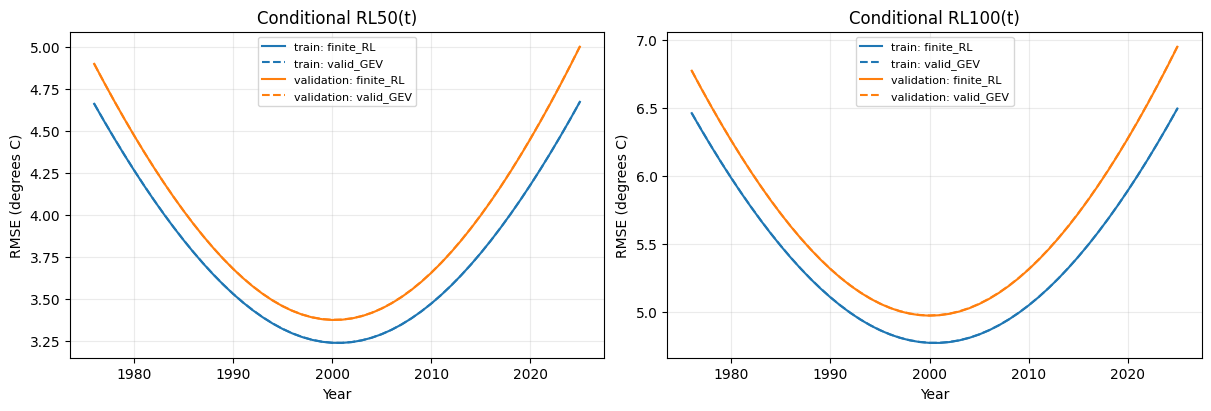

In [6]:
rl_by_year = pd.DataFrame()
rl_overall = pd.DataFrame()
if rl_year_tables:
    rl_by_year = pd.concat(rl_year_tables, ignore_index=True)
    rl_overall = pd.concat(rl_overall_tables, ignore_index=True)
    show_table(rl_overall, 'return_level_overall.csv', len(rl_overall))
    if SAVE_OUTPUTS and TABLE_DIR is not None:
        rl_by_year.to_csv(TABLE_DIR / 'return_level_by_year.csv', index=False)
    show_figure(plot_rl_by_year(rl_by_year), 'diagnostic_return_level_rmse_by_year.png')
else:
    print('Return-level plots are waiting for saved predictions.')


## 6. 哪些模擬條件容易出錯？

以下以 validation（或你指定的 `DETAIL_SPLIT`）檢查最後一年 RL 誤差，依真值的 $\xi_0$、$\beta_\mu/\sigma_0$、$\beta_\sigma$ 分組。每個點上方是「使用數／總數」，避免忽略某些組的數值失敗。

這裡用相同寬度、由原始抽樣範圍決定的 bins；不是依誤差挑選區間。誤差在邊界變大時，可研究增加該區間訓練樣本、摘要是否保留足夠資訊，或模型是否偏向中心；**不應只刪掉困難樣本來降低分數**。

若想比較新方案：保留這次 run，另開新 run；用相同 validation 設計比較，最終方案再揭露 test。


,factor,left,right,midpoint,year,return_period,n_total,n_used,n_excluded,RMSE,MAE,bias,split
0,xi0,-0.400,-0.300,-0.3500,2025,50,1221,1221,0,1.6067,0.9563,0.3863,validation
1,xi0,-0.400,-0.300,-0.3500,2025,100,1221,1221,0,1.8360,1.0858,0.5601,validation
2,xi0,-0.300,-0.200,-0.2500,2025,50,1272,1272,0,1.8950,1.1050,0.2528,validation
3,xi0,-0.300,-0.200,-0.2500,2025,100,1272,1272,0,2.2177,1.2739,0.3968,validation
4,xi0,-0.200,-0.100,-0.1500,2025,50,1229,1229,0,2.3969,1.3643,0.1000,validation
5,xi0,-0.200,-0.100,-0.1500,2025,100,1229,1229,0,2.8636,1.6351,0.2137,validation
6,xi0,-0.100,0.000,-0.0500,2025,50,1211,1211,0,3.3445,1.9070,0.1627,validation
7,xi0,-0.100,0.000,-0.0500,2025,100,1211,1211,0,4.1500,2.3812,0.3184,validation
8,xi0,0.000,0.100,0.0500,2025,50,1217,1217,0,4.1434,2.2912,0.0774,validation
9,xi0,0.000,0.100,0.0500,2025,100,1217,1217,0,5.4419,2.9900,0.2360,validation


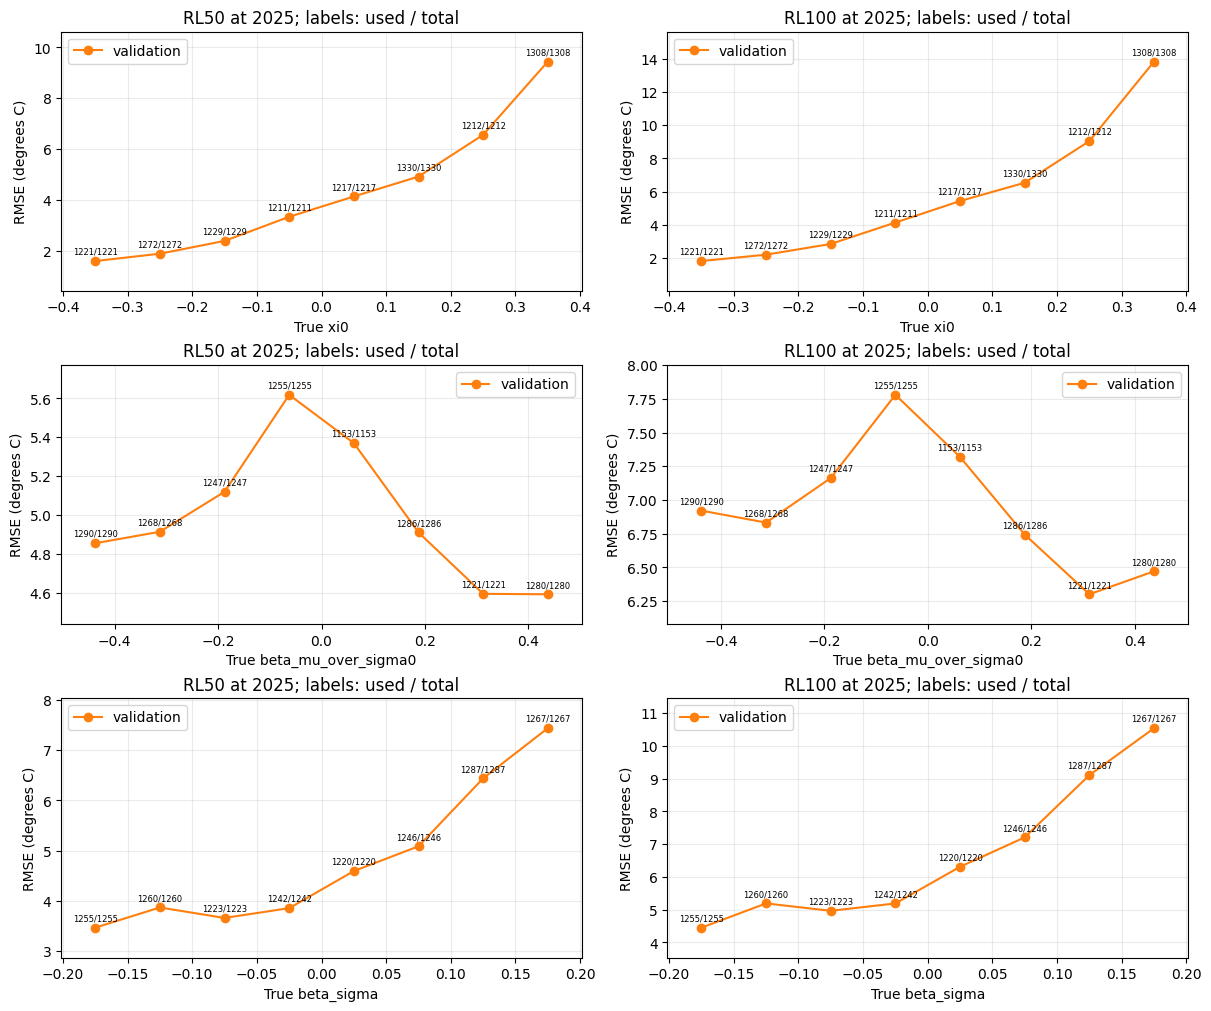

Saved figures: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\cheng_nn_17d\run_20260929_gpu_01\figures
Saved diagnostic tables: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\cheng_nn_17d\run_20260929_gpu_01\diagnostics_tables


In [7]:
if DETAIL_SPLIT in predictions_by_split:
    binned_errors = binned_rl_errors(data_by_split[DETAIL_SPLIT], predictions_by_split[DETAIL_SPLIT]).assign(split=DETAIL_SPLIT)
    show_table(binned_errors, f'{DETAIL_SPLIT}_binned_return_level_errors.csv', len(binned_errors))
    show_figure(plot_binned_rl_errors(binned_errors), f'diagnostic_{DETAIL_SPLIT}_binned_return_level_errors.png')
else:
    print(f'{DETAIL_SPLIT}: binned error analysis is waiting for saved predictions.')

print('Saved figures:', FIGURE_DIR if SAVE_OUTPUTS else 'disabled')
print('Saved diagnostic tables:', TABLE_DIR if SAVE_OUTPUTS else 'disabled')
